# Phase 7: NLP and Text Analysis
## London Airbnb Analysis - Mohan Raju Kolikonda

Anlysing guest review text to answer Business Question 3: does review sentiment predict a listings overall review score, and what drive negative reviews? 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

reviews = pd.read_csv('../data/reviews_clean.csv', parse_dates=['date'])
listings = pd.read_csv('../data/listings_clean.csv')

print("Reviews:", reviews.shape)
print("Date range:", reviews['date'].min(), "to", reviews['date'].max().date())

Reviews: (978778, 5)
Date range: 2024-07-01 00:00:00 to 2026-06-30


### NLP Pipeline

**Tool:** VADER (Valence Aware Dictionary and sEntiment Reasoner), via NLTK.

**Why chosen:** VADER is rule-based and needs no labelled training data, which suits reviews that have no sentiment labels. It is tuned for short, informal text, matching the style of guest reviews.

**Method:** A random sample of 100,000 reviews (random_state=42 for reproducibility) scored on VADER's compound scale from −1 to +1, classified using VADER's conventional thresholds: negative below −0.05, positive above +0.05.

**Known limitation:** VADER scores English text only. London reviews include substantial French, German, Spanish and Italian text, which is scored near-neutral regardless of content. This is measured and addressed explicitly below.

In [2]:
SAMPLE_SIZE = 100_000
sample = reviews.sample(SAMPLE_SIZE, random_state=42).copy()
sample['comments'] = sample['comments'].astype(str)

sia = SentimentIntensityAnalyzer()
sample['sentiment'] = sample['comments'].apply(lambda t: sia.polarity_scores(t)['compound'])

sample['sentiment_label'] = pd.cut(sample['sentiment'],
                             bins=[-1, -0.05, 0.05, 1.0],
                             labels=['Negative', 'Neutral', 'Positive'])

print(sample['sentiment_label'].value_counts())
print(sample['sentiment'].describe().round(3))
print(f"Sampled {len(sample):,} of {len(reviews):,} reviews")

sentiment_label
Positive    78193
Neutral     14661
Negative     7146
Name: count, dtype: int64
count    100000.000
mean          0.601
std           0.474
min          -0.996
25%           0.401
50%           0.836
75%           0.945
max           0.999
Name: sentiment, dtype: float64
Sampled 100,000 of 978,778 reviews


In [3]:
def looks_english(text):
    common = {'the', 'and', 'was', 'is', 'we', 'our', 'very', 'stay', 'place'}
    t = '' + str(text).lower() + ''
    return sum(w in t for w in common) >=2

sample['is_english'] = sample['comments'].apply(looks_english)
print(f"Estimated English: {sample['is_english'].mean():.1%}")
print(f"Non-English: {(~sample['is_english']).sum():,} reviews")

Estimated English: 73.7%
Non-English: 26,336 reviews


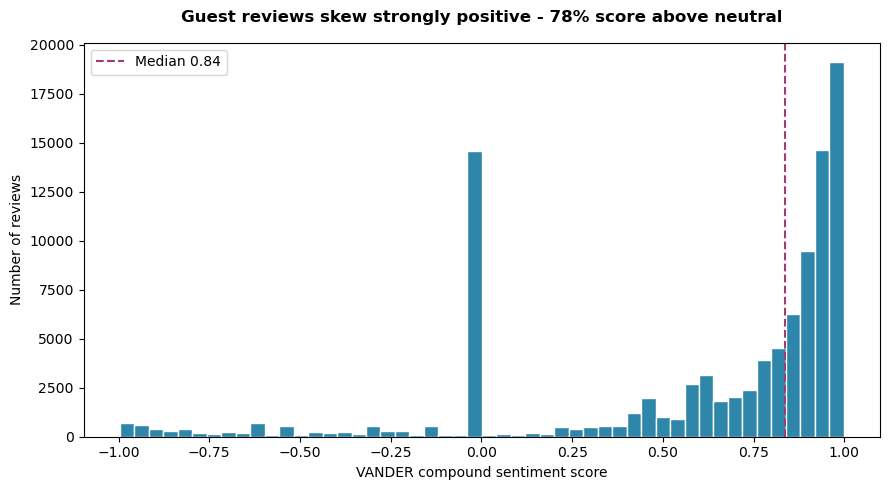

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(sample['sentiment'], bins=50, color='#2E86AB', edgecolor='white')
ax.axvline(sample['sentiment'].median(), color='#A23B72', linestyle='--',
           label=f"Median {sample['sentiment'].median():.2f}")
ax.set_xlabel('VANDER compound sentiment score')
ax.set_ylabel('Number of reviews')
ax.set_title('Guest reviews skew strongly positive - 78% score above neutral',
             fontweight='bold', fontsize=12, pad=15)
ax.legend()
plt.tight_layout()
fig.savefig('../charts/chart5_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**What:** Sentiment is heavily skewed positive: 78.2% of the 100,000 sampled reviews score above neutral, 14.7% are neutral and 7.1% negative. Median compound score is 0.836.

**So What:** Written reviews suffer the same ceiling effect as star ratings — most guests write positively, so the small negative tail carries disproportionate information. The neutral band is also inflated by the 26.3% of reviews not written in English, which VADER cannot score.

**Now What:** Analysis of problem themes should focus on the negative tail, filtered to English-language reviews, rather than treating average sentiment as a performance measure.

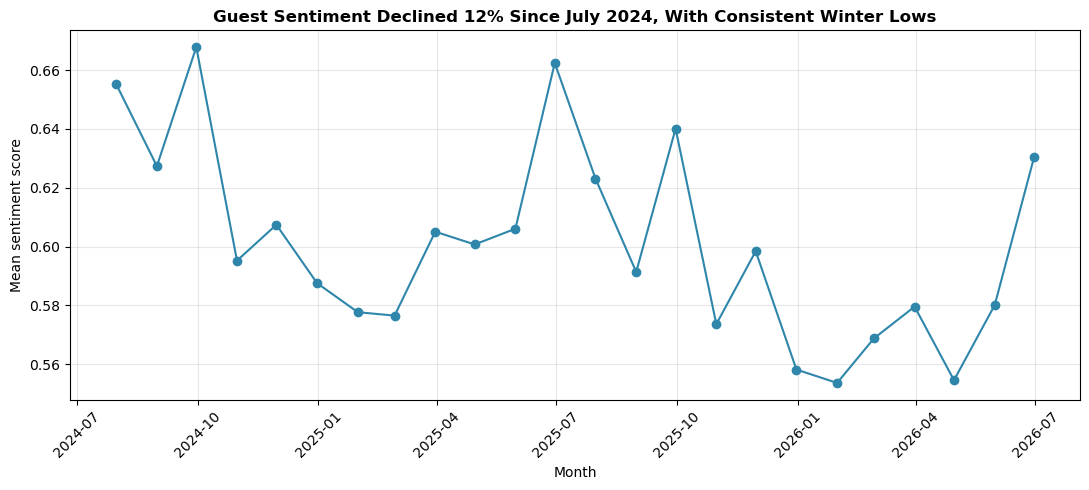

         date   mean  count
0  2024-07-31  0.655   4129
1  2024-08-31  0.627   3613
2  2024-09-30  0.668   3299
3  2024-10-31  0.595   3598
4  2024-11-30  0.607   3278
5  2024-12-31  0.588   3660
6  2025-01-31  0.578   2605
7  2025-02-28  0.577   2482
8  2025-03-31  0.605   3205
9  2025-04-30  0.601   3711
10 2025-05-31  0.606   4089
11 2025-06-30  0.662   5046
12 2025-07-31  0.623   5620
13 2025-08-31  0.591   4980
14 2025-09-30  0.640   4828
15 2025-10-31  0.574   4877
16 2025-11-30  0.598   4747
17 2025-12-31  0.558   5039
18 2026-01-31  0.554   3494
19 2026-02-28  0.569   3461
20 2026-03-31  0.580   4468
21 2026-04-30  0.555   5445
22 2026-05-31  0.580   6387
23 2026-06-30  0.630   3939


In [5]:
monthly_sent = (sample.set_index('date')
                .resample('ME')['sentiment']
                .agg(['mean', 'count'])
                .reset_index())

monthly_sent = monthly_sent[monthly_sent['count'] >= 100]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_sent['date'], monthly_sent['mean'], marker='o', color='#2E86AB')
ax.set_xlabel('Month')
ax.set_ylabel('Mean sentiment score')
ax.set_title('Guest Sentiment Declined 12% Since July 2024, With Consistent Winter Lows', fontweight='bold')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig('../charts/chart6_sentiment_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(monthly_sent.round(3))
            
            

**What:** Mean monthly sentiment fell from 0.655 in July 2024 to around 0.57 through 2026 — a decline of roughly 12%. Winter months are consistently lowest (December 2025: 0.558, January 2026: 0.554) while summer peaks higher (June 2025: 0.662).

**So What:** The seasonal pattern mirrors the review-volume seasonality found in Phase 5: winter brings both fewer bookings and less satisfied guests, likely reflecting weather, heating and daylight issues in short-let properties. The gradual decline warrants monitoring, though part may reflect changing sample composition rather than falling standards.

**Now What:** Winter operational readiness — heating, hot water, damp — should be a due-diligence check on acquisition targets, since properties are judged most harshly in exactly the months when demand is weakest.

Negative reviews: 7,146


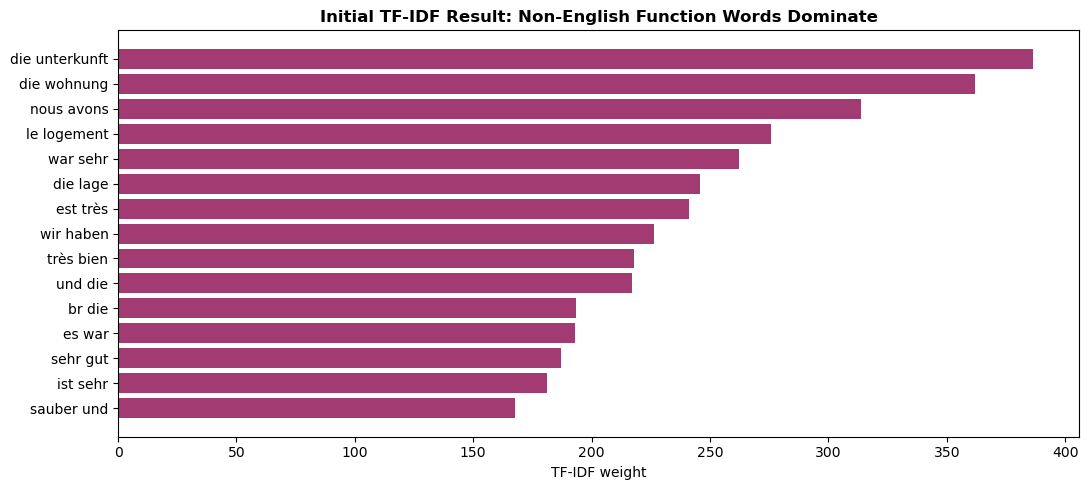

die unterkunft    386.498127
die wohnung       361.990171
nous avons        313.705327
le logement       275.849913
war sehr          262.169662
die lage          245.752247
est très          241.338166
wir haben         226.198898
très bien         217.930516
und die           217.031573
br die            193.221492
es war            192.997387
sehr gut          186.880950
ist sehr          181.220471
sauber und        167.606244
dtype: float64


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

negative = sample[sample['sentiment_label'] == 'Negative']['comments']
print(f"Negative reviews: {len(negative):,}")

tfidf = TfidfVectorizer(max_features=25, stop_words='english',
                        ngram_range=(2, 3), min_df=10)

matrix = tfidf.fit_transform(negative)

scores = pd.Series(matrix.sum(axis=0).A1, index=tfidf.get_feature_names_out())
top_phrases = scores.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top_phrases.index[::-1], top_phrases.values[::-1], color='#A23B72')
ax.set_xlabel('TF-IDF weight')
ax.set_title('Initial TF-IDF Result: Non-English Function Words Dominate', fontweight='bold')
plt.tight_layout()
fig.savefig('../charts/chart7a_initial_language.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_phrases)



### Key Phrase Extraction: Initial Result

TF-IDF extraction of two- and three-word phrases from reviews classified as negative returned the following top 15 terms:

| Phrase | Weight | Language |
|---|---|---|
| die unterkunft | 386.5 | German ("the accommodation") |
| die wohnung | 362.0 | German ("the flat") |
| nous avons | 313.7 | French ("we have") |
| le logement | 275.8 | French ("the accommodation") |
| war sehr | 262.2 | German ("was very") |
| die lage | 245.8 | German ("the location") |
| est très | 241.3 | French ("is very") |
| wir haben | 226.2 | German ("we have") |
| très bien | 217.9 | French ("very good") |
| sehr gut | 186.9 | German ("very good") |
| sauber und | 167.6 | German ("clean and") |

**Interpretation:** No English themes appear, and several of the extracted phrases are explicitly positive ("sehr gut", "très bien", "sauber und"). This is not a finding about guest complaints — it is a demonstration of the VADER limitation documented in the pipeline section.

**Why this happened:** VADER scores English text only. Reviews written in other languages receive compound scores close to zero, and a proportion fall below the −0.05 negative threshold. Language detection showed that 26.3% of the sampled reviews are not in English, so the "negative" set is substantially contaminated with non-English reviews that are not negative at all.

**Consequence for the analysis:** Sentiment scores for the non-English quarter of the corpus are unreliable, which also attenuates the measured correlation between sentiment and review score. Negative-theme extraction requires filtering to English-language reviews before the results can be interpreted as guest complaints.

In [7]:
negative_en = sample[(sample['sentiment_label'] == 'Negative') & sample['is_english']]['comments']
print(f"English negative reviews: {len(negative_en):,}")

tfidf = TfidfVectorizer(max_features=25, stop_words='english',
                        ngram_range=(2, 3), min_df=10)
matrix = tfidf.fit_transform(negative_en)
scores = pd.Series(matrix.sum(axis=0).A1, index=tfidf.get_feature_names_out())
top_phrases = scores.sort_values(ascending=False).head(15)
print(top_phrases)

English negative reviews: 4,427
nous avons        258.014021
die unterkunft    250.844964
die wohnung       237.247917
le logement       204.706501
est très          176.509801
wir haben         150.707854
die lage          150.644210
und die           150.203037
très bien         150.015916
je recommande     144.264941
br die            143.713598
war sehr          140.585308
ist sehr          135.006207
sehr gut          117.861235
das zimmer        107.115505
dtype: float64


In [8]:
%pip install langdetect

Note: you may need to restart the kernel to use updated packages.


In [9]:
# In Anaconda Prompt first: pip install langdetect
from langdetect import detect, LangDetectException

def detect_lang(text):
    try:
        return detect(str(text)[:400])
    except LangDetectException:
        return 'unknown'

neg = sample[sample['sentiment_label'] == 'Negative'].copy()
neg['lang'] = neg['comments'].apply(detect_lang)
print(neg['lang'].value_counts().head(8))

negative_en = neg[neg['lang'] == 'en']['comments']
print(f"\nEnglish negative reviews: {len(negative_en):,}")

tfidf = TfidfVectorizer(max_features=25, stop_words='english',
                        ngram_range=(2, 3), min_df=10)
matrix = tfidf.fit_transform(negative_en)
scores = pd.Series(matrix.sum(axis=0).A1, index=tfidf.get_feature_names_out())
print(scores.sort_values(ascending=False).head(15))

lang
de    2604
en    1681
fr    1298
es    1031
pt     171
nl     133
it     101
pl      20
Name: count, dtype: int64

English negative reviews: 1,681
hot water          68.229778
great location     42.862163
didn work          40.392544
br overall         38.054218
good location      37.120835
br host            35.764574
place stay         34.585577
living room        33.552257
toilet paper       33.118109
sofa bed           31.304691
br apartment       30.885741
check time         30.822756
stay br            29.115736
washing machine    29.114559
tube station       25.310094
dtype: float64


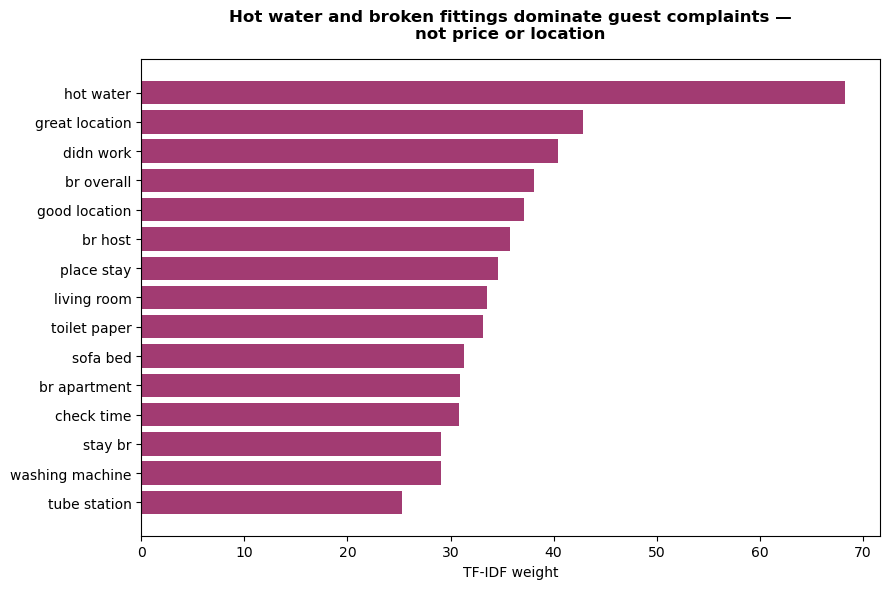

In [10]:
top_phrases = scores.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_phrases.index[::-1], top_phrases.values[::-1], color='#A23B72')
ax.set_xlabel('TF-IDF weight')
ax.set_title('Hot water and broken fittings dominate guest complaints —\nnot price or location',
             fontweight='bold', fontsize=12, pad=15)
plt.tight_layout()
fig.savefig('../charts/chart7_negative_phrases.png', dpi=150, bbox_inches='tight')
plt.show()

### Negative Themes (English-language reviews)

Language detection on the 7,146 reviews classified as negative found only 1,680 were English — German (2,605), French (1,298) and Spanish (1,031) together made up the majority, confirming that VADER had misclassified non-English text. Themes below are extracted from the English subset only.

**What:** The strongest complaint term by some margin is "hot water" (68.2), followed by "didn't work" (40.4). The remaining themes are operational and specific: toilet paper, washing machine, sofa bed, living room, and check-in timing. Location terms ("great location", "good location", "tube station") appear because guests use them concessively — praising location while complaining about the property.

**So What:** Guests complain about operations and maintenance, not about price, décor or neighbourhood. This connects directly to the Phase 5 finding that superhost listings are booked 83 nights a year against zero for the median non-superhost: the difference between a listing that trades and one that does not appears to be operational reliability rather than asset quality.

**Now What:** For the Head of Portfolio, two implications follow. First, acquisition due diligence should prioritise heating and hot-water systems, since these generate the most complaints. Second, the operational standard applied after acquisition may matter more to performance than which borough the property sits in — supporting investment in property management capability alongside acquisition spend.